In [5]:
import pandas as pd
import numpy as np
from scipy import stats

from pandas.api.types import CategoricalDtype

stationProximityDataSet: pd.DataFrame = pd.read_csv("data/benz-tr.csv")

# Drop rows where country is not czechia

stationProximityDataSet = stationProximityDataSet[stationProximityDataSet.country == "cze"]

# Lets consider rows which have the same amnt, day, hour, clid to be duplicate and drop them
duplicateSubset = subset=["amt", "day", "hour", "clid"]

stationProximityDataSet = stationProximityDataSet.drop_duplicates(subset=duplicateSubset)

# Drop useless columns
stationProximityDataSet = stationProximityDataSet.drop(columns=["clst", "clid", "day", "hour", "fav", "fav_main", "cl_gps_lat", "cl_gps_lon", "name", "dist", "country"])

stationsWithDifferingGPS = stationProximityDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

duplicateSubset = ["gps_lat", "gps_lon"]

stationsWithDifferingGPS = stationProximityDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    city=("city", "first"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

stationsWithDifferingGPS = stationsWithDifferingGPS.groupby(['gps_lat', 'gps_lon'], as_index=False).agg(
    total_amt=('total_amt', 'sum'),
    posid=('posid', 'first'),
    city=('city', 'first')
)

In [6]:

networkStationPairs = pd.read_csv("./data/network_station_pairs_cities_only.csv")

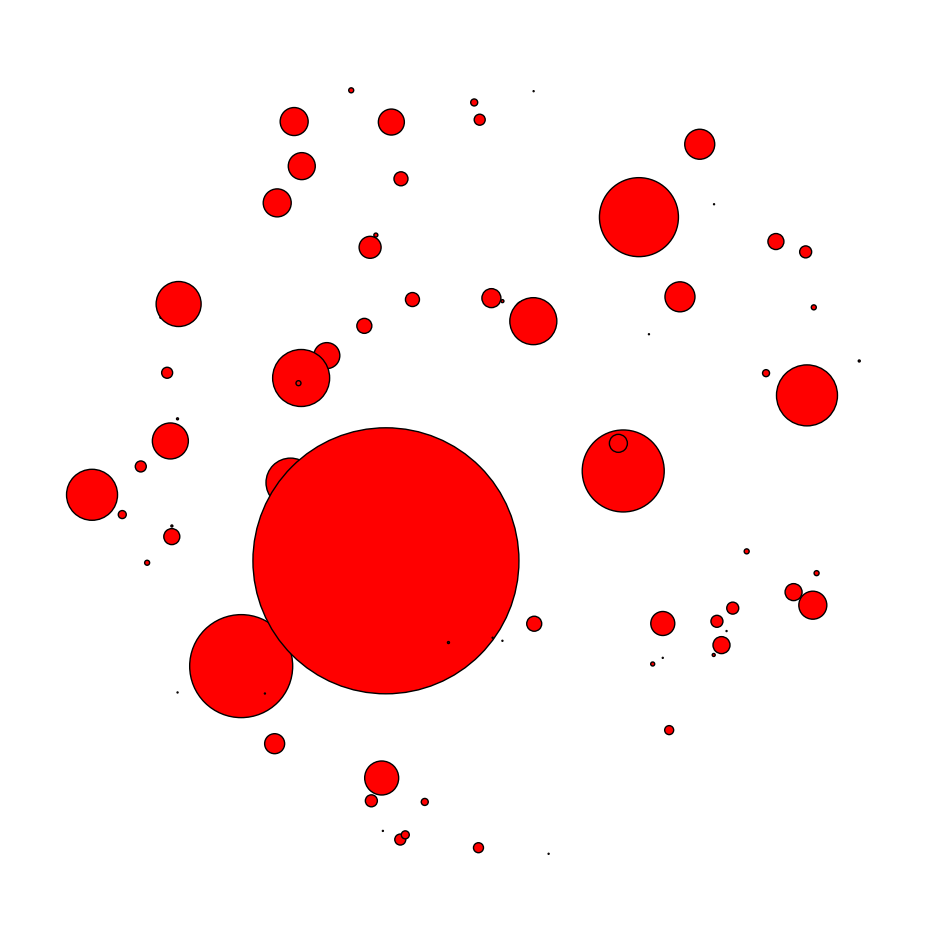

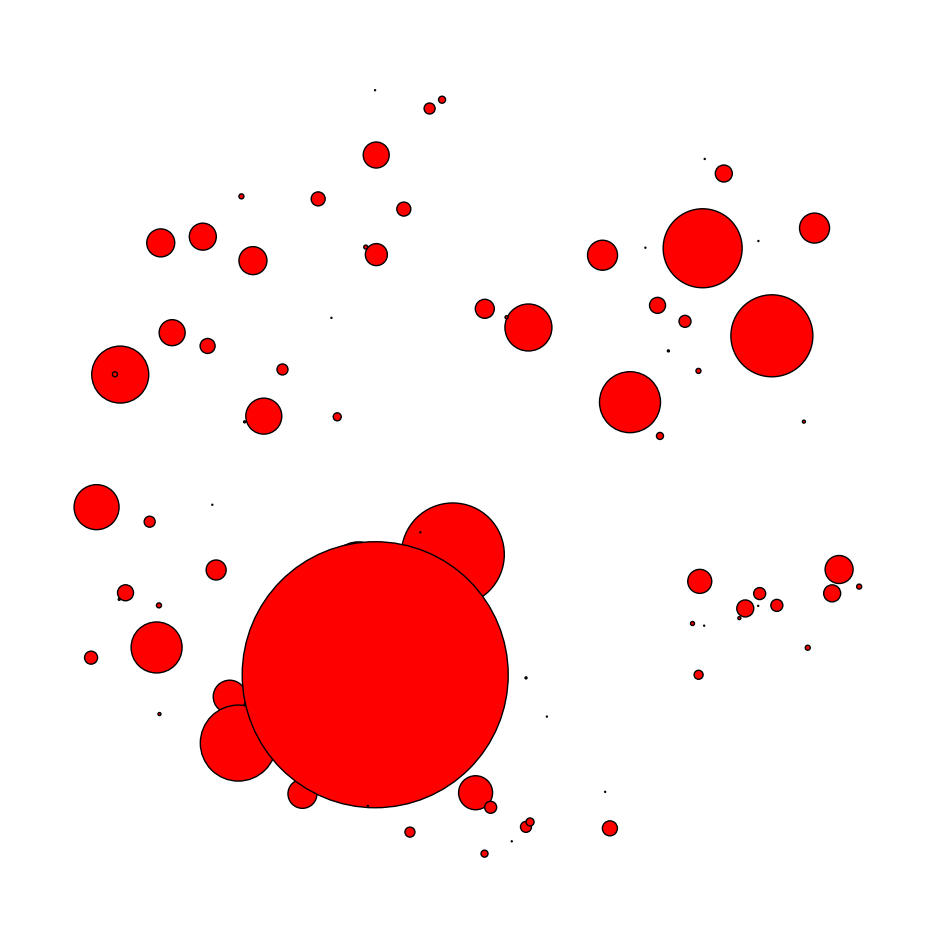

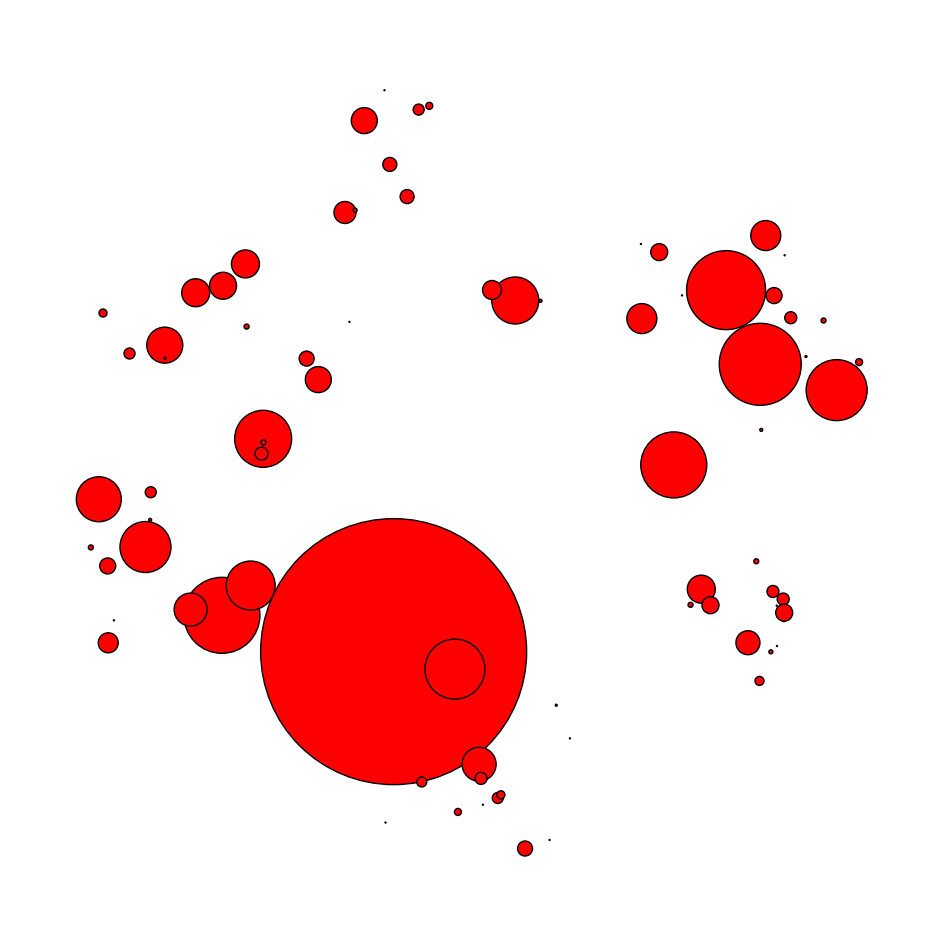

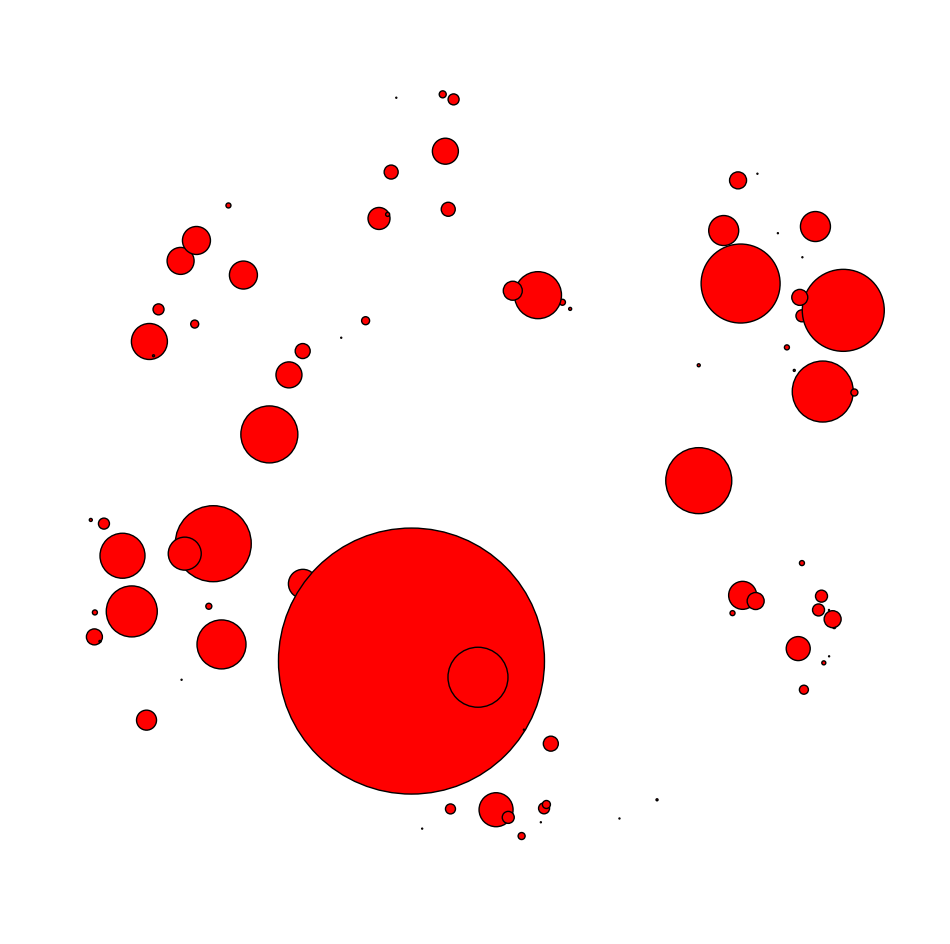

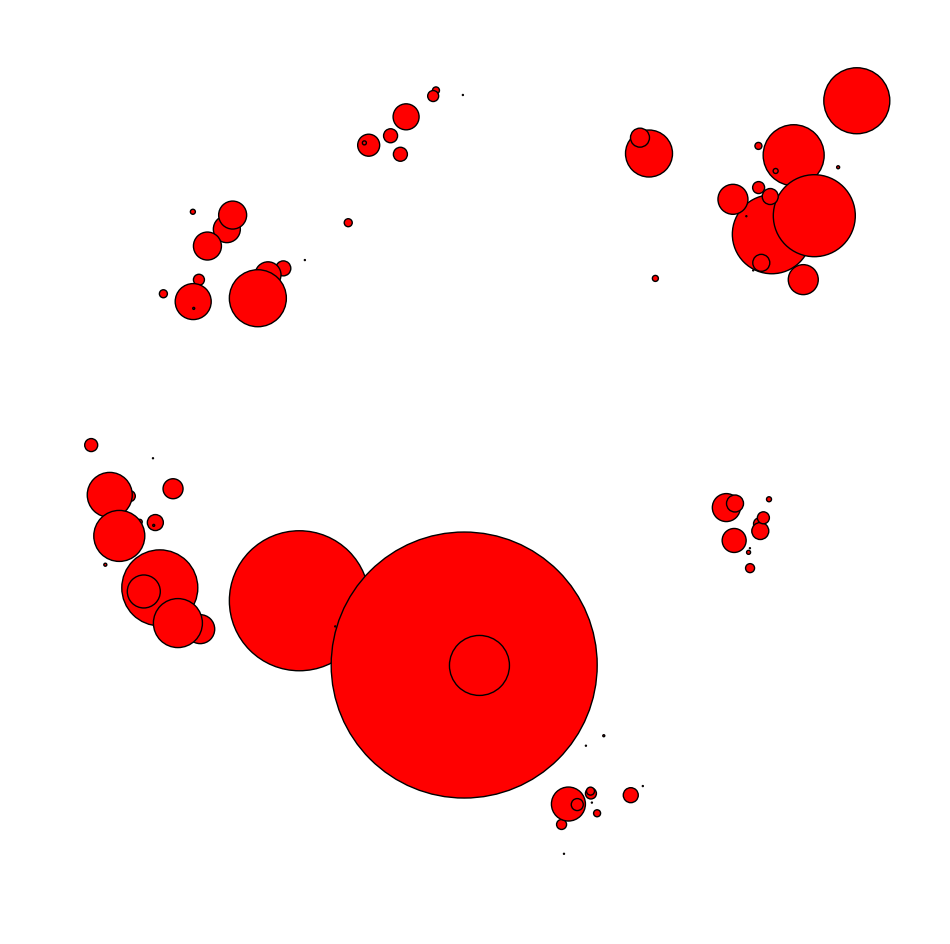

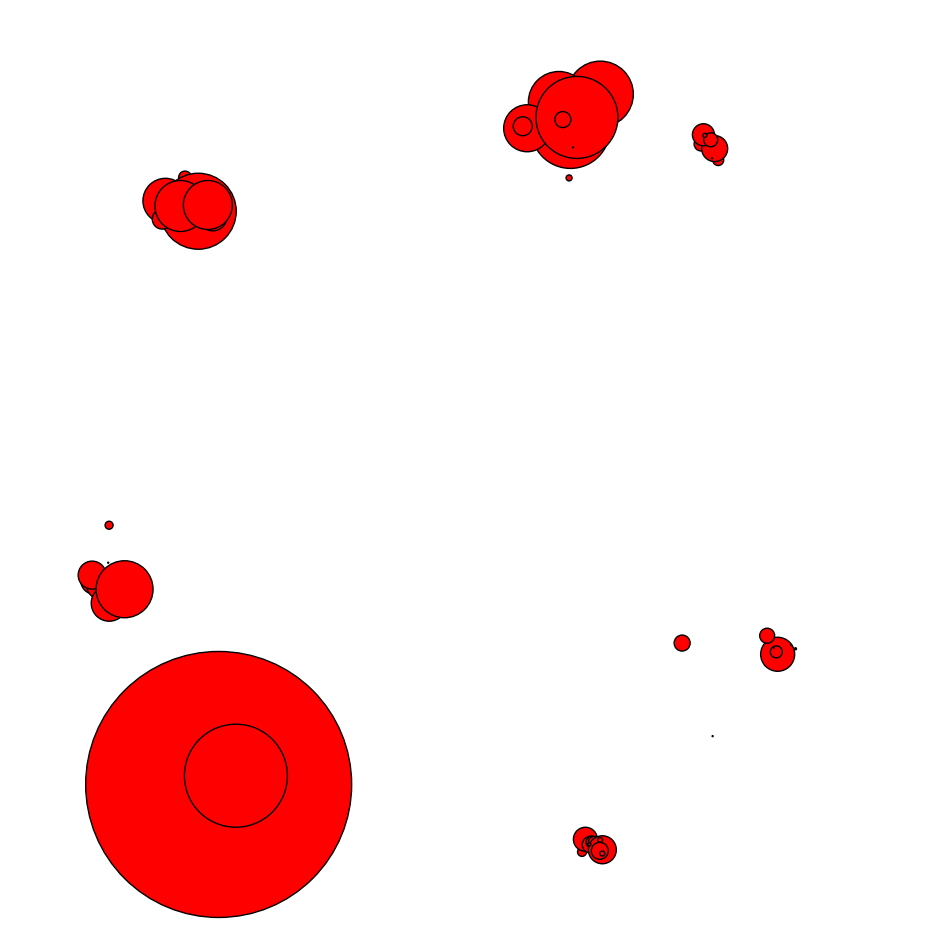

In [7]:
import igraph as ig
import matplotlib.pyplot as plt

radii = [2,4,6,8, 50, 100]
stationParisLimitedPerRadius = []

for i in radii:
    stationParisLimitedPerRadius.append(networkStationPairs[networkStationPairs["distance"] <= i])

for stationsPairsLimited in stationParisLimitedPerRadius:
    g = ig.Graph.TupleList(stationsPairsLimited.itertuples(index=False), weights=True)

    node_sizes = dict(zip(stationsWithDifferingGPS["posid"], stationsWithDifferingGPS["total_amt"].apply(lambda x: x / 100000)))

    g.vs["size"] = [node_sizes.get(posid, 1) for posid in g.vs["name"]]

    layout = g.layout("kamada_kawai", weights=g.es["weight"])

    fig, ax = plt.subplots(figsize=(12, 12))  # Larger figure size for better visualization
    ig.plot(g, layout=layout, target=ax, vertex_size=g.vs["size"], bbox=(0, 0, 1000, 1000), edge_width=0)

    plt.show()

In [8]:
stationsWithDifferingGPS

,gps_lat,gps_lon,total_amt,posid,city
0,48.587223,14.322222,17905.70,8062,studanky
1,48.619080,14.324732,106154.00,8685,vyssi brod
2,48.624376,14.248910,13322.30,6390,loucovice
3,48.637203,14.230956,134472.40,6440,lipno nad vlt
4,48.649460,14.452580,2319653.78,5090,dolni dvoriste
...,...,...,...,...,...
2143,51.000679,14.575062,4610.02,5712,jirikov
2144,51.002682,14.464286,187055.20,7936,sluknov
2145,51.004217,14.456016,1946.80,7939,sluknov
2146,51.024219,14.456202,5294.10,7937,sluknov


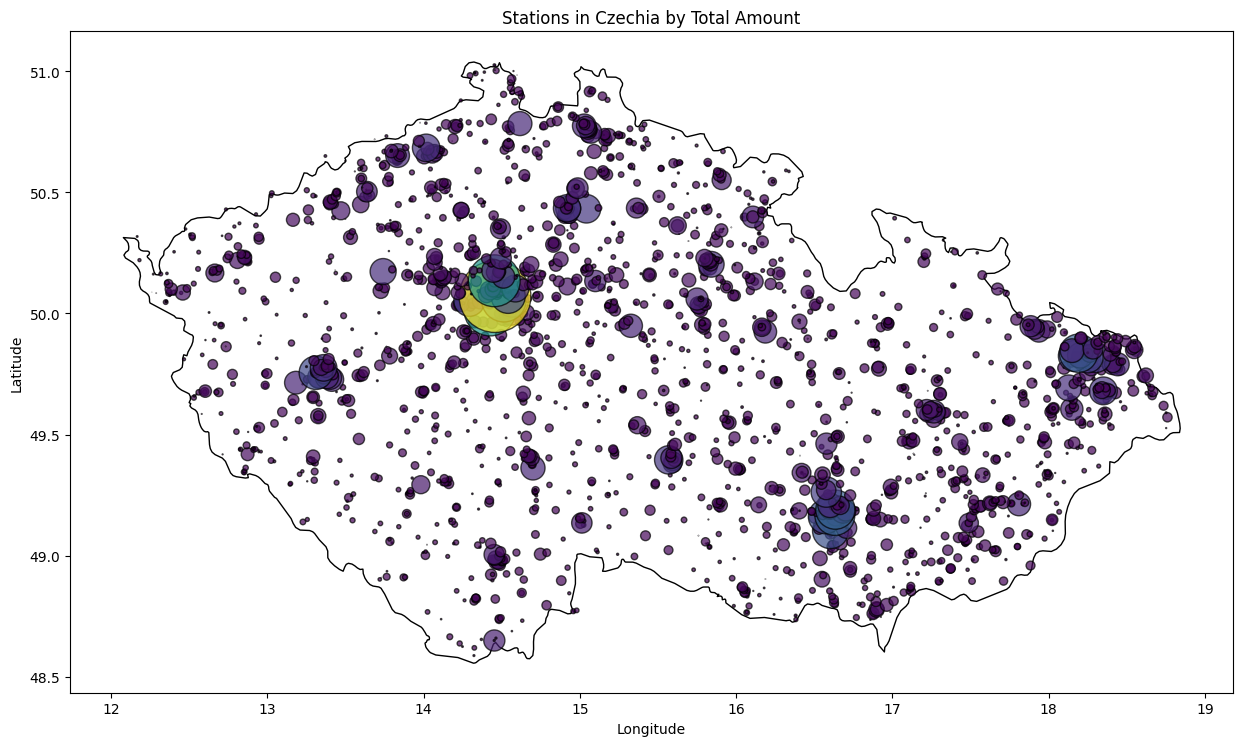

In [11]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point

world = gpd.read_file('./maps/ne_10m_admin_0_countries.shp')

czech_map = world[world['NAME'] == 'Czechia']

geometry = [Point(xy) for xy in zip(stationsWithDifferingGPS['gps_lon'], stationsWithDifferingGPS['gps_lat'])]

gdf_points = gpd.GeoDataFrame(stationsWithDifferingGPS, geometry=geometry, crs="EPSG:4326")

marker_sizes = gdf_points['total_amt'] * 0.0001  # Scale factor to adjust the size

fig, ax = plt.subplots(figsize=(15, 15))
czech_map.plot(ax=ax, color='white', edgecolor='black')

gdf_points.plot(
    ax=ax,
    column='total_amt',   # Color scale based on 'total_amt'
    cmap='viridis',       # Colormap
    markersize=marker_sizes,  # Size based on 'total_amt'
    alpha=0.7,            # Transparency for better visibility
    edgecolor='black'
)

plt.title('Stations in Czechia by Total Amount')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [26]:
networkStationPairs

,posid_1,posid_2,distance
0,4585,4704,6.88
1,4585,37580,9.94
2,4585,37579,10.26
3,4585,37589,9.99
4,4585,4599,9.92
...,...,...,...
5773,6147,37637,82.36
5774,6147,37695,4.28
5775,6147,8812,2.90
5776,6147,6148,3.08


In [40]:
# Drop useless columns
dataSet = pd.read_csv("data/benz-tr.csv")
czechiaOnlyDataSet = dataSet[dataSet.country == "cze"]
czechiaOnlyDataSet = czechiaOnlyDataSet.drop(columns=["clst", "clid", "day", "hour", "fav", "fav_main", "cl_gps_lat", "cl_gps_lon", "name", "dist", "country"])

stationsDataSet = czechiaOnlyDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    city=('city', 'first')
)
print("There are", (stationsDataSet.shape)[0], "unique posid values, but there might be some duplicates.")
print("Since we also have gps coordinates of the stations and their precision is up to 5 or 6 decimal places, which is precise up to 0.1 meters, we will consider stations sharing same gps to be duplicate.")

duplicateSubset = ["gps_lat", "gps_lon"]

print('\nCount of duplicated gps locations is',
      sum(stationsDataSet.duplicated(subset=duplicateSubset)))

stationsWithDifferingGPS = stationsDataSet.groupby(['gps_lat', 'gps_lon'], as_index=False).agg(
    total_amt=('total_amt', 'sum'),
    posid=('posid', 'first'),
    city=('city', 'first')
)

print("Our final count of stations is", (stationsWithDifferingGPS.shape)[0])

from geopy.distance import geodesic

major_cities_coords = {
    'praha': (50.073658, 14.418540),
    'brno': (49.195061, 16.606836),
    'ostrava': (49.820923, 18.262524),
    'liberec': (50.766280, 15.054339),
    'plzen': (49.738430, 13.373637),
    'olomouc': (49.593777, 17.250879),
    'budejovice': (48.975658, 14.480255),
    'hradec kralove': (50.210361, 15.825211)
}


radius = 30

def is_near_major_city(lat, lon, rowCity, cities_coords, radius_km):
    for city, coords in cities_coords.items():
        if city.startswith(rowCity):
            return True
        if geodesic((lat, lon), coords).km <= radius_km:
            return True
    return False

stationsWithDifferingGPS['near_major_city'] = stationsWithDifferingGPS.apply(
    lambda row: is_near_major_city(row['gps_lat'], row['gps_lon'], row['city'], major_cities_coords, radius),
    axis=1
)

stationsWithDifferingGPS = stationsWithDifferingGPS[stationsWithDifferingGPS['near_major_city']]

stationsWithDifferingGPS = stationsWithDifferingGPS.drop(columns='near_major_city')
print("That leaves us with", (stationsWithDifferingGPS.shape)[0], "stations.")

There are 3000 unique posid values, but there might be some duplicates.
Since we also have gps coordinates of the stations and their precision is up to 5 or 6 decimal places, which is precise up to 0.1 meters, we will consider stations sharing same gps to be duplicate.

Count of duplicated gps locations is 851
Our final count of stations is 2148
That leaves us with 843 stations.


In [41]:
radii = [0.5,1, 2,4,6,8,10,20]
stationPairsLimitedPerRadius = []

for i in radii:
    stationPairsLimitedPerRadius.append(networkStationPairs[networkStationPairs["distance"] <= i])

In [38]:
stationInRadiusPerRadius = []

for stationsPairsLimited in stationPairsLimitedPerRadius:
    # Melt the DataFrame to unify posid_1 and posid_2
    stationDistances = pd.melt(
        stationsPairsLimited,
        id_vars=['distance'],
        value_vars=['posid_1', 'posid_2'],
        var_name='pos_type',
        value_name='posid'
    )

    stationDistances = stationDistances.drop('pos_type', axis=1)

    stationsInRadius = stationDistances.groupby("posid").agg(
        stations_in_radius=("distance", "count"),
        posid=("posid", "first")
    )

    stationsInRadius = stationsInRadius.set_index("posid").join(stationsWithDifferingGPS.set_index("posid"))

    stationsInRadius = stationsInRadius.reindex(stationsWithDifferingGPS["posid"]).fillna(0)

    stationsInRadius = stationsInRadius.drop(columns=["gps_lat", "gps_lon"], errors='ignore')

    stationInRadiusPerRadius.append(stationsInRadius)

    print(stationsInRadius[stationsInRadius["stations_in_radius"] == 0])


       stations_in_radius  total_amt city
posid                                    
4413                  0.0        0.0    0
5767                  0.0        0.0    0
5765                  0.0        0.0    0
5762                  0.0        0.0    0
4851                  0.0        0.0    0
...                   ...        ...  ...
5241                  0.0        0.0    0
5247                  0.0        0.0    0
5248                  0.0        0.0    0
5267                  0.0        0.0    0
5242                  0.0        0.0    0

[816 rows x 3 columns]
       stations_in_radius  total_amt city
posid                                    
4413                  0.0        0.0    0
5767                  0.0        0.0    0
5765                  0.0        0.0    0
5762                  0.0        0.0    0
4851                  0.0        0.0    0
...                   ...        ...  ...
5241                  0.0        0.0    0
5247                  0.0        0.0    0
5248      

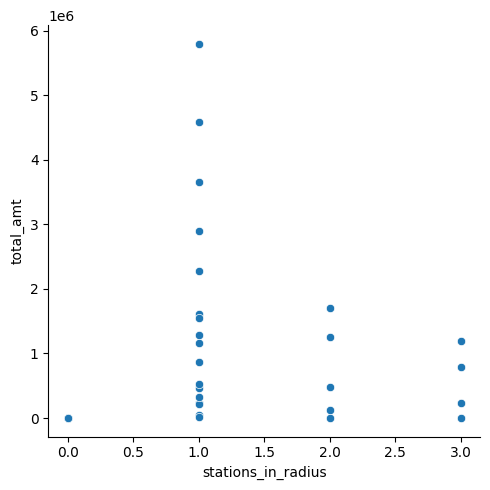

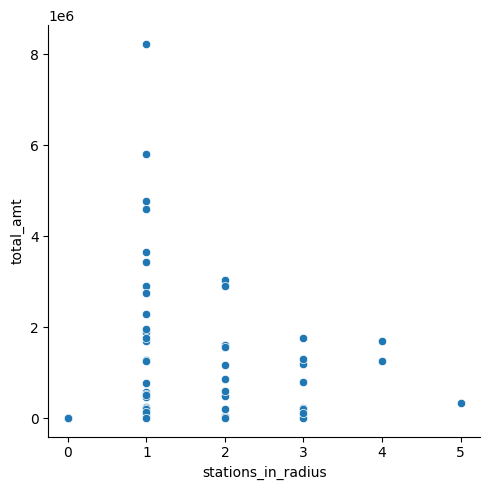

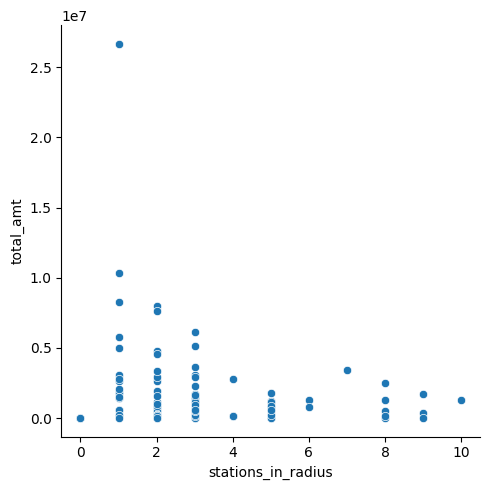

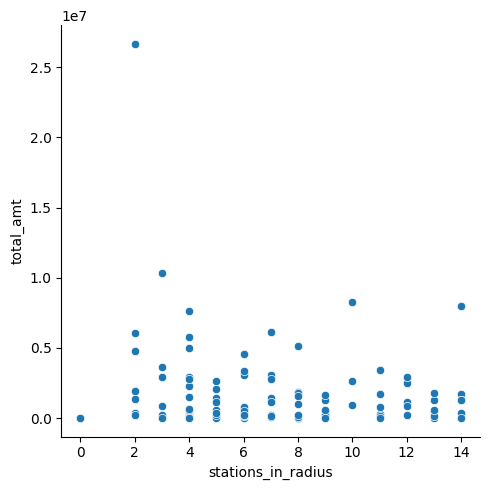

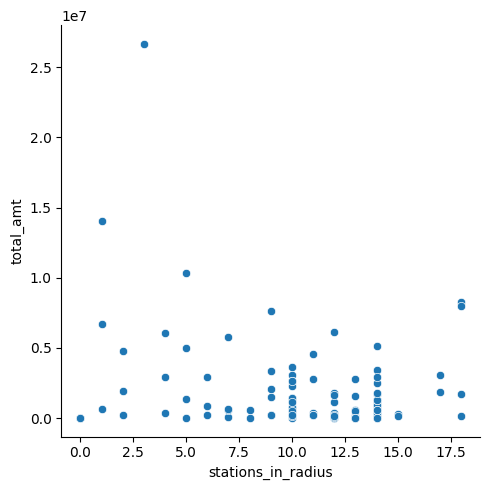

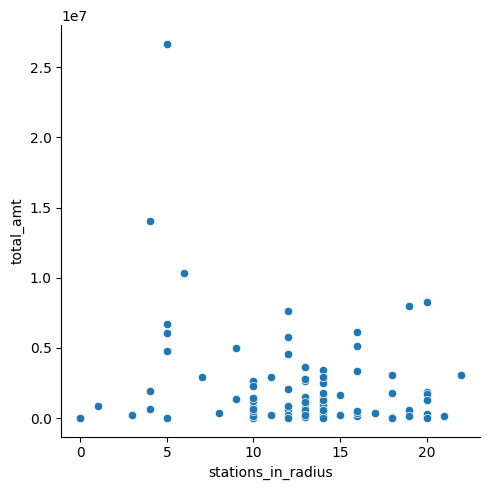

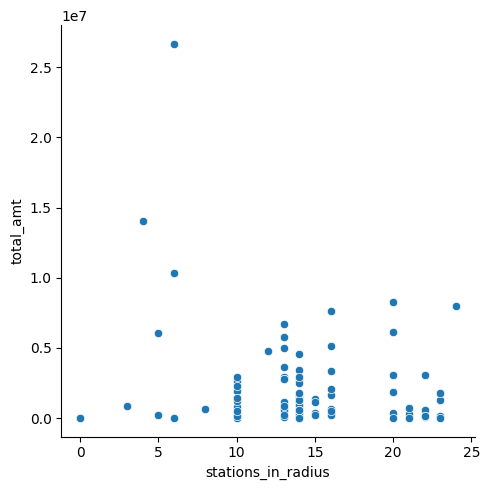

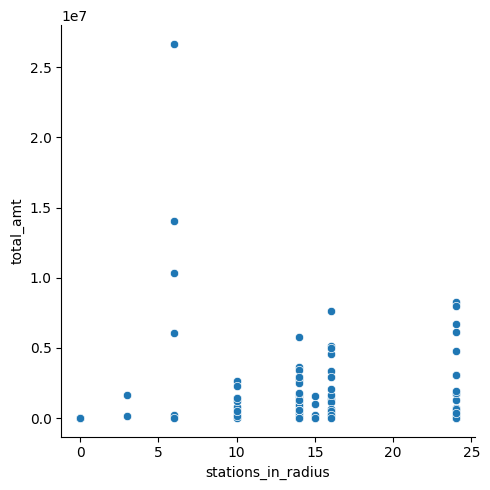

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.precision", 2)

for stationsInRadius in stationInRadiusPerRadius:
    g = sns.relplot(data=stationsInRadius, x="stations_in_radius", y="total_amt")

# Linear Regression

In [28]:
stationsInRadius = stationInRadiusPerRadius[2]
stationsInRadius

,stations_in_radius,total_amt
posid,,
37579,3,1.98e+02
37755,2,1.73e+03
4599,2,2.37e+03
6874,5,3.09e+03
6149,9,3.76e+03
...,...,...
6971,2,4.59e+06
7183,1,5.80e+06
4704,3,5.86e+06


In [35]:
stationsInRadius = stationInRadiusPerRadius[2]
X = stationsInRadius[['stations_in_radius']]
y = stationsInRadius['total_amt']

### fit model
modelA = LinearRegression().fit(X, y)

### get coefficients
print('Intercept: ', modelA.intercept_)
print('Beta coefficients: ', modelA.coef_)

### assess coefficients / drop predictors
# There is no straight way (like p-value). We can use performance metric and assess it;
# then we can fit a submodel and compare performance metrics.

### assess model performance
# i. scoring itself directly (not recommended, overrates performance)
print('R2 on itself: ', modelA.score(X, y))

# ii. scoring by a cross-validation
scores = cross_val_score(LinearRegression(), X, y, cv=4)
print('R2 by cval: ', scores)

### predictions
x_pred = 10 # prediction of amount for 2 stations in radius
print('Predicted intake for stations in radius', x_pred, ' is ', modelA.predict([[x_pred]]))
# predictions can be made on actual predictor values, too -> added to the chart

Intercept:  114824.6215790669
Beta coefficients:  [261429.76147264]
R2 on itself:  0.07015675243037722
R2 by cval:  [ 0.12593379  0.14590979  0.02008322 -3.79019006]
Predicted intake for stations in radius 10  is  [2729122.23630546]


c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [106]:
X_int = sm.add_constant(X)
# by default the intercept is NOT included - we need to add it

### fit model
modelB = sm.OLS(y, X_int).fit()

### get coefficients
print('Beta coefficients: ', modelB.params)

### assess coefficients / drop predictors
print(modelB.summary()) # detailed information of model and coefficients

### assess model
# i. scoring itself directly (not recommended, overrates performance)
print('R2 on itself: ', modelB.rsquared)
# ii. scoring by a cross-validation
# cross-validation not available in this package, we can use approximation:
print('R2 adjusted: ', modelB.rsquared_adj)

### predictions
x_pred = 2 # prediction of salary for 35 yrs old
print('Predicted intake for stations in radius', x_pred, ' is ', modelB.predict([1, x_pred]))

Beta coefficients:  const                 1.50e+06
stations_in_radius   -1.20e+05
dtype: float64
                            OLS Regression Results                            
Dep. Variable:              total_amt   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     6.136
Date:                Fri, 10 Jan 2025   Prob (F-statistic):             0.0144
Time:                        19:01:54   Log-Likelihood:                -2366.0
No. Observations:                 152   AIC:                             4736.
Df Residuals:                     150   BIC:                             4742.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

In [98]:
X = stationsInRadius[['stations_in_radius']]
y = stationsInRadius['total_amt']

# A. sklearn
modelA = LinearRegression().fit(X, y)
# and everything is the same...
print('Intercept: ', modelA.intercept_)
print('Beta coefficients: ', modelA.coef_)
print('R2 on itself: ', modelA.score(X, y))
scores = cross_val_score(LinearRegression(), X, y, cv=4)
print('R2 by cval: ', scores)
# except prediction - it must use follow dummy (one-hot) encoding, i.e. "male" -> sex_M=1
x_pred = 3
print('Predicted intake for stations in radius ', x_pred, ' is ', modelA.predict([[x_pred]]))

Intercept:  1504468.6525603018
Beta coefficients:  [-120005.46221859]
R2 on itself:  0.039301784849202326
R2 by cval:  [-641.25161302  -58.76132866   -3.81107109   -2.44281656]
Predicted intake for stations in radius  3  is  [1144452.26590452]


c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
